In [50]:
# Import Labraries
import pandas as pd
import matplotlib.pyplot as plt
import ast

# Data & Cleaning
df = pd.read_csv(r'C:\Users\PC\Documents\Learning_PYTHON\data_jobs.csv')
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply ( lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# You will learn how to make Scatter Chart 

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [52]:
# Prepare the data fram
job_title = 'Data Analyst'
df = df[df['job_title_short']==job_title]

In [56]:
df_exploded = df.explode('job_skills')

# Now you need to count the skills and calcule the median salary
skills_status = df_exploded.groupby('job_skills').agg(
    skills_count = ('job_skills' , 'count') ,
    median_salary = ('salary_year_avg' , 'median')
    )

skills_status = skills_status.sort_values(by='skills_count' , ascending=False).head(25)

skills_status

,skills_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


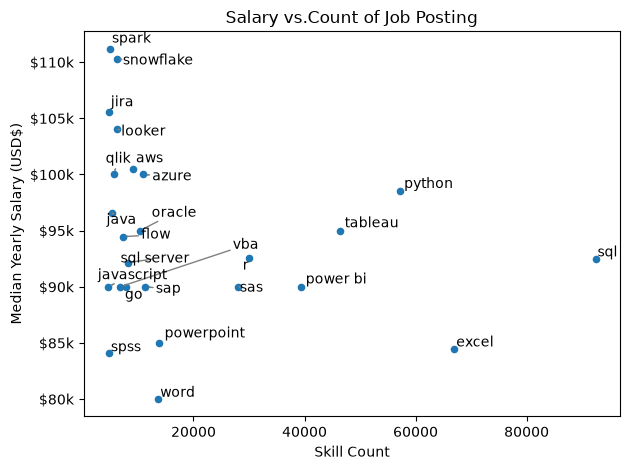

In [61]:
# You can plot it now 
# We are gonna to customise the Adjust Text to making this scatter better

from adjustText import adjust_text

skills_status.plot(kind='scatter' , x='skills_count' , y='median_salary')
plt.title('Salary vs.Count of Job Posting')
plt.xlabel("Skill Count")
plt.ylabel("Median Yearly Salary (USD$)")

texts = []            # this is for customisation
for i,txt in enumerate(skills_status.index) : 
    texts.append(plt.text(skills_status['skills_count'].iloc[i] , skills_status['median_salary'].iloc[i] , txt ) )

adjust_text ( texts , arrowprops=dict(arrowstyle='->' , color='gray' , lw=1)  )

# Lets transforme the y axis from  100000 to $100K
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos : f'${int(y/1000)}k') )

plt.tight_layout()
plt.show()